In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
df = pd.read_csv("atlas-higgs-challenge-2014-v2.csv.gz")
df.head(25)

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,...,PRI_jet_all_pt,Weight,Label,KaggleSet,KaggleWeight
0,100000,138.470,51.655,97.827,27.980,...,113.497,0.000814,s,t,0.002653
1,100001,160.937,68.768,103.235,48.146,...,46.226,0.681042,b,t,2.233584
2,100002,-999.000,162.172,125.953,35.635,...,44.251,0.715742,b,t,2.347389
3,100003,143.905,81.417,80.943,0.414,...,-0.000,1.660654,b,t,5.446378
4,100004,175.864,16.915,134.805,16.405,...,0.000,1.904263,b,t,6.245333
5,100005,89.744,13.550,59.149,116.344,...,193.660,0.025434,b,t,0.083414
6,100006,148.754,28.862,107.782,106.130,...,179.877,0.000814,s,t,0.002653
7,100007,154.916,10.418,94.714,29.169,...,30.638,0.005721,s,t,0.018636
8,100008,105.594,50.559,100.989,4.288,...,0.000,1.614803,b,t,5.296003
9,100009,128.053,88.941,69.272,193.392,...,167.735,0.000461,s,t,0.001502


NOTE:
Any data with the value -999 is a NaN value -- another way of writing NaN.

The Label column of the above data set includes a value of "b" or "s".
b = background
s = signal
The background data will be plotted against the signal data.

In [3]:
# Converting all values in the dataframe to floats (excluding the variables, 'Label', and 'KaggleSet')
variables = ['EventId', 'DER_mass_MMC', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi',
       'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi',
       'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt',
       'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt',
       'Weight', 'KaggleWeight']

for column in variables:
    df[column] = pd.to_numeric(df[column], errors="coerce")


# Converting 'Label', and 'KaggleSet' column to strings
label_and_kaggle = ['Label', 'KaggleSet']

for column in label_and_kaggle:
    df[column] = df[column].astype('string')

In [16]:
# Replacing -999 values with NaN values
df_replaced = df.replace(-999, np.nan) 

# Droping events (rows) containing NaN values
df_droped = df_replaced.dropna(axis=0)
df_droped
# Switching the columns and rows of the data. This makes cleaning the data easier
# The event number is specified at the top of each column, starting at 100000
df_transposed = df_droped.set_index('EventId').T
df_transposed.index.name = 'EventID'
df_transposed.reset_index(inplace=True)
df_transposed.columns.name = None
# df_transposed

In [13]:
# Seperating the data based on the label column
background_cols = []  # By adding all events labeled as background or signal into a series, it prevents crashing due to the size of the dataframe
signal_cols = []

for column in df_transposed.columns:
    if df_transposed.loc[31, column] == 'b':     # If labeled as background, column name (event) is moved to background_cols
        background_cols.append(column)
    elif df_transposed.loc[31, column] == 's':   # If labeled as signal, column name (event) is moved to signal_cols
        signal_cols.append(column)

df_background = df_transposed[background_cols].copy()    # Transfering columns in background_cols into its own dataframe
df_signal = df_transposed[signal_cols].copy()            # Transfering columns in signal_cols into its own dataframe
df_background

df_background.insert(0, 'EventID', df_transposed['EventID'])  # Adding the Variable column as the first cloumn in the new dataframes
df_signal.insert(0, 'EventID', df_transposed['EventID'])
print(df_background.shape)  # Checking shape of dataframes
print(df_signal.shape)

# Prepering for ploting by removing any rows without numbers
df_background_nums = df_background.drop(labels = [31, 32]) # background dataframe with numbers only
df_signal_nums = df_signal.drop(labels = [31, 32])         # signal dataframe with numbers only

(34, 118936)
(34, 104640)


In [23]:
# Switching the rows and columns of background and signal because I realized it would be easier to plot with this format

df_background2 = df_background_nums.set_index('EventID').T
df_background2.index.name = 'EventID'
df_background2.reset_index(inplace=True)
df_background2.columns.name = None

df_signal2 = df_signal_nums.set_index('EventID').T
df_signal2.index.name = 'EventID'
df_signal2.reset_index(inplace=True)
df_signal2.columns.name = None

In [62]:
# Plotting the data

df_background2

,EventID,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,KaggleWeight
0,100005,89.744,13.55,59.149,116.344,2.636,284.584,-0.54,1.362,61.619,...,3,90.547,-2.412,-0.653,56.165,0.224,3.106,193.66,0.025434,0.083414
1,100011,114.744,10.286,75.712,30.816,2.563,252.599,-1.401,2.888,36.745,...,3,76.773,-0.79,0.303,56.876,1.773,-2.079,165.64,0.093659,0.30717
2,100029,98.761,14.024,74.23,132.806,3.676,315.854,-2.665,1.261,23.29,...,2,80.627,0.993,-2.018,32.625,-2.683,-1.467,113.252,0.09446,0.309795
3,100033,123.112,62.758,86.702,39.901,3.16,244.181,-2.139,2.825,9.732,...,2,71.127,2.177,0.558,32.515,-0.983,-2.628,103.642,0.346119,1.135152
4,100045,27.788,68.032,23.53,33.375,1.37,78.189,3.443,0.78,10.201,...,2,37.734,2.663,-0.491,32.666,1.293,-2.358,70.4,0.584376,1.916554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118930,918196,299.596,222.874,128.399,131.423,1.288,245.989,1.217,2.871,21.828,...,3,188.754,1.921,0.292,59.063,0.633,-2.06,292.209,0.22687,10.163918
118931,918199,129.397,97.647,104.956,42.335,0.872,98.14,-0.179,2.626,35.831,...,2,46.618,0.54,1.702,42.679,-0.332,-1.144,89.297,0.336595,15.079643
118932,918200,114.108,70.028,67.157,49.654,0.697,212.019,1.071,3.108,17.702,...,2,125.253,-1.441,-3.064,79.911,-0.743,0.328,205.164,0.09446,4.231848
118933,918206,102.272,0.203,71.423,228.856,1.082,121.679,0.308,0.967,22.461,...,2,108.476,0.234,2.753,99.88,1.316,2.818,208.356,0.022533,1.009473


In [104]:
# FIRST: Randomizes the remaing non-NaN data to shrink the amount of data

# Removes 99.832% of the rows within the background dataframe or 200 rows are kept
df_small_background = df_background2.drop(df_background2.sample(frac=0.99832).index) 

# Removes 99.809% of the rows within the signal dataframe or 200 rows are kept
df_small_signal = df_signal2.drop(df_signal2.sample(frac=0.99809).index) 

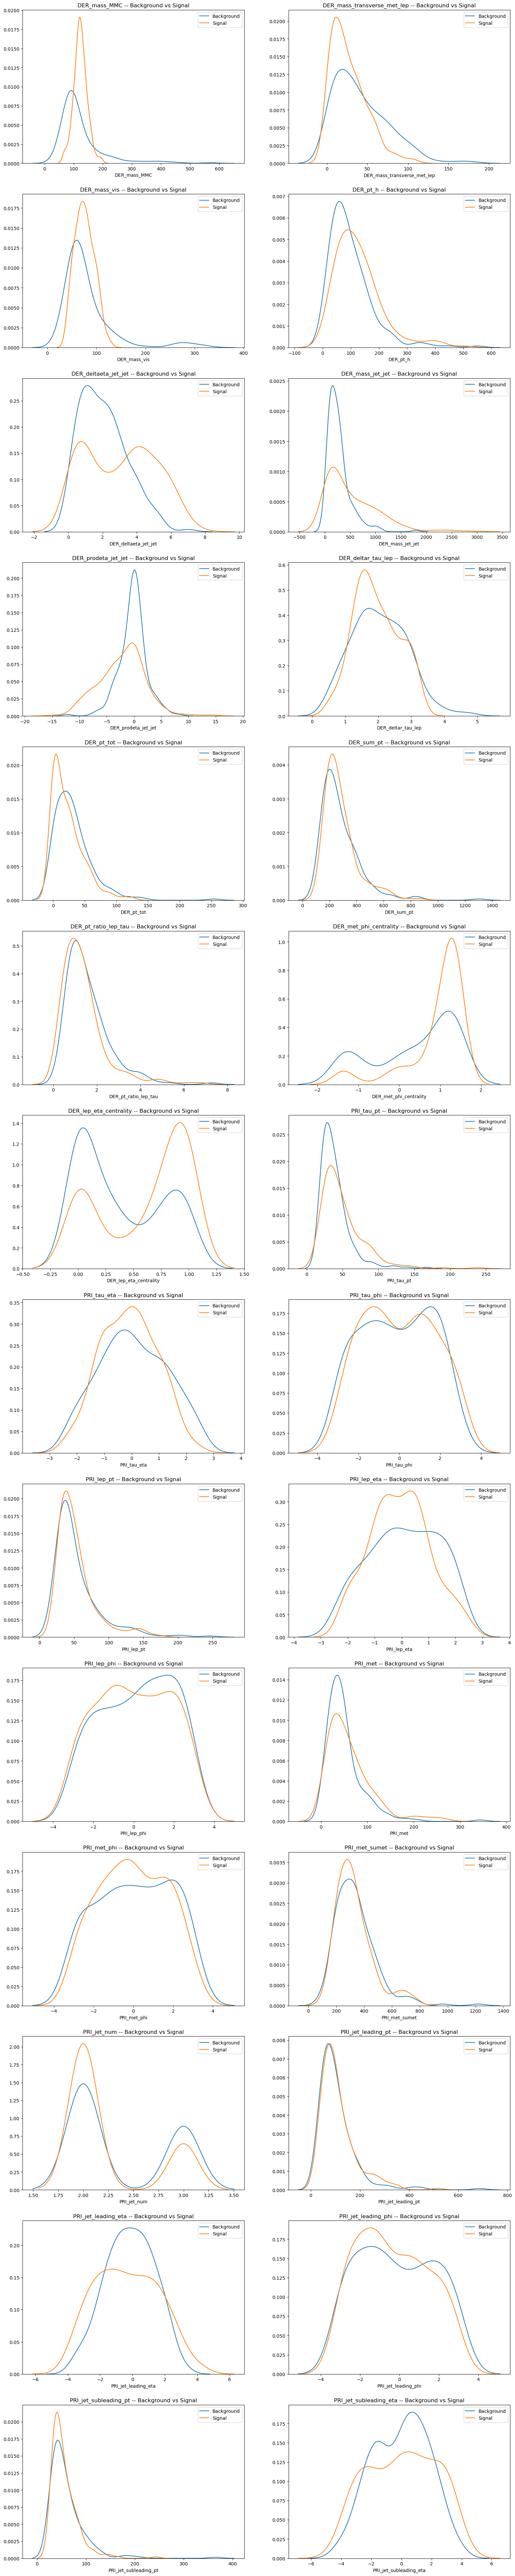

In [98]:
# Plotting the 1st randomized data

# Setting up zip function
# Not including the 'Weight' and the 'Kaggleweight' in the graphs
background_columns = ['DER_mass_MMC', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi',
       'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi',
       'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt',
       'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt']
signal_columns = ['DER_mass_MMC', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi',
       'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi',
       'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt',
       'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt']
titles = ['DER_mass_MMC -- Background vs Signal', 'DER_mass_transverse_met_lep -- Background vs Signal',
       'DER_mass_vis -- Background vs Signal', 'DER_pt_h -- Background vs Signal', 'DER_deltaeta_jet_jet -- Background vs Signal',
       'DER_mass_jet_jet -- Background vs Signal', 'DER_prodeta_jet_jet -- Background vs Signal', 
       'DER_deltar_tau_lep -- Background vs Signal', 'DER_pt_tot -- Background vs Signal', 'DER_sum_pt -- Background vs Signal',
       'DER_pt_ratio_lep_tau -- Background vs Signal', 'DER_met_phi_centrality -- Background vs Signal',
       'DER_lep_eta_centrality -- Background vs Signal', 'PRI_tau_pt -- Background vs Signal',
       'PRI_tau_eta -- Background vs Signal', 'PRI_tau_phi -- Background vs Signal', 'PRI_lep_pt -- Background vs Signal', 
       'PRI_lep_eta -- Background vs Signal', 'PRI_lep_phi -- Background vs Signal', 'PRI_met -- Background vs Signal',
       'PRI_met_phi -- Background vs Signal', 'PRI_met_sumet -- Background vs Signal', 'PRI_jet_num -- Background vs Signal',
       'PRI_jet_leading_pt -- Background vs Signal', 'PRI_jet_leading_eta -- Background vs Signal', 
       'PRI_jet_leading_phi -- Background vs Signal', 'PRI_jet_subleading_pt -- Background vs Signal',
       'PRI_jet_subleading_eta -- Background vs Signal', 'PRI_jet_subleading_phi -- Background vs Signal', 
       'PRI_jet_all_pt -- Background vs Signal']
xlabels = ['DER_mass_MMC', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi',
       'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi',
       'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt',
       'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt']

# Looping through each variable in the two random 200 background and signal events and plotting two respective lines.
# The greater the y value, the greater the likeleyhood of that variable to signify backgreound or signal.
fig, axes = plt.subplots(14, 2, figsize=(19,100))
for ax, (col_b, background_series), (col_s, signal_series), title, xlabel in zip(axes.ravel(), 
    df_small_background[background_columns].items(),
    df_small_signal[signal_columns].items(), titles, xlabels):
    sns.kdeplot(background_series.values, ax=ax, label='Background')
    sns.kdeplot(signal_series.values, ax=ax, label='Signal')
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')

In [91]:
# SECOND: Randomizes the remaing non-NaN data to shrink the amount of data

# Removes 99.832% of the rows within the background dataframe or 200 rows are kept
df_small_background2 = df_background2.drop(df_background2.sample(frac=0.99832).index) 

# Removes 99.809% of the rows within the signal dataframe or 200 rows are kept
df_small_signal2 = df_signal2.drop(df_signal2.sample(frac=0.99809).index) 

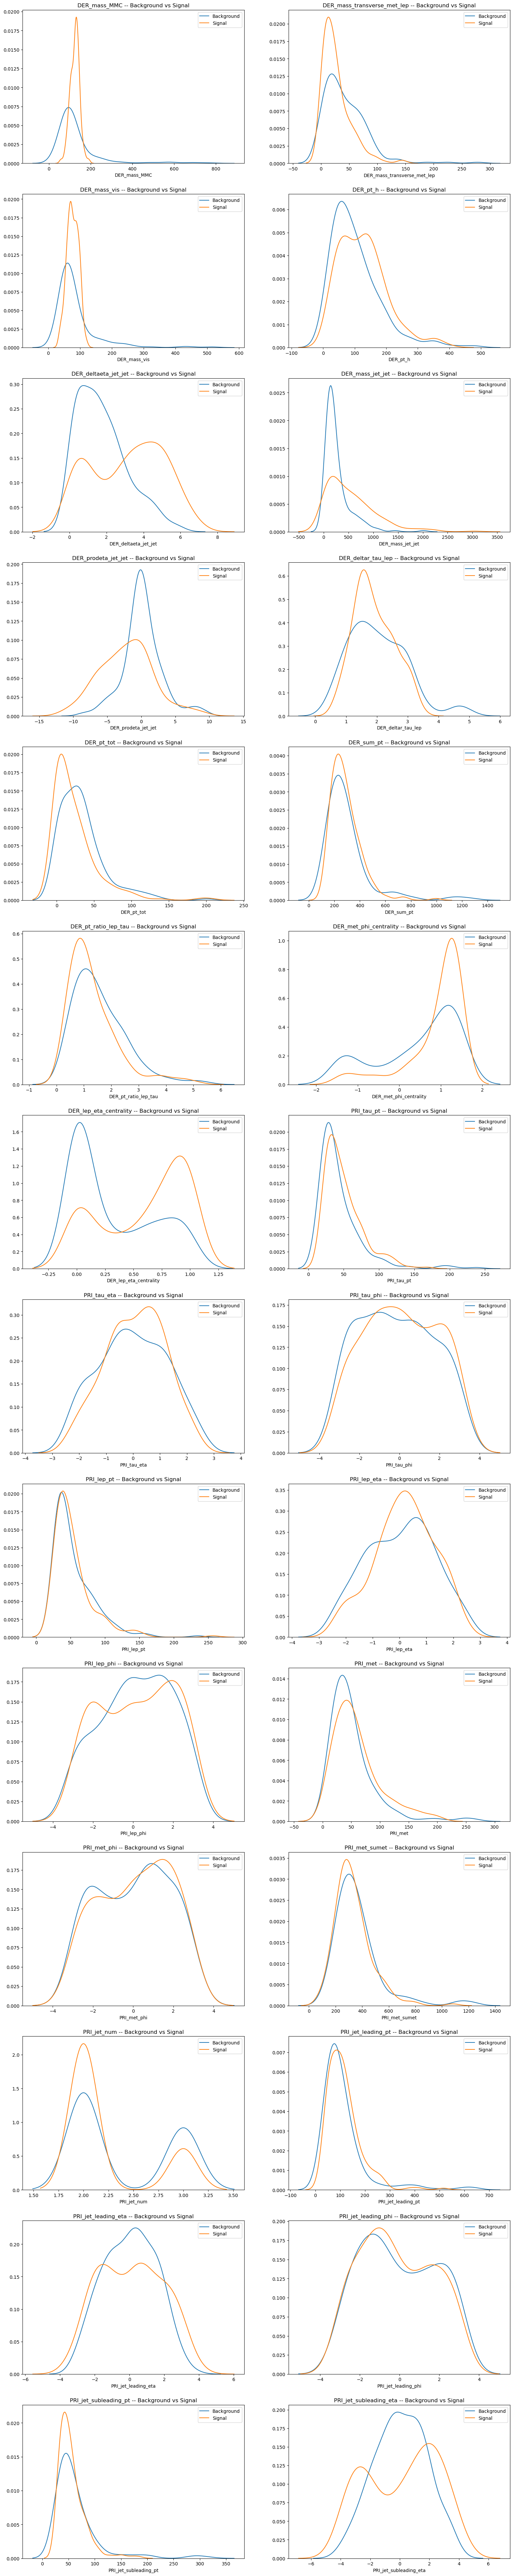

In [92]:
# Plotting the 2nd randomized data

# Looping through each variable in the two random 200 background and signal events and plotting two respective lines.
# The greater the y value, the greater the likeleyhood of that variable to signify backgreound vs signal.
fig, axes = plt.subplots(14, 2, figsize=(19,100))
for ax, (col_b, background_series), (col_s, signal_series), title, xlabel in zip(axes.ravel(), 
    df_small_background2[background_columns].items(),
    df_small_signal2[signal_columns].items(), titles, xlabels):
    sns.kdeplot(background_series.values, ax=ax, label='Background')
    sns.kdeplot(signal_series.values, ax=ax, label='Signal')
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
plt.savefig('Signal_vs_Background.png', dpi=300, bbox_inches='tight')

In [93]:
# THIRD: Randomizes the remaing non-NaN data to shrink the amount of data

# Removes 99.832% of the rows within the background dataframe or 200 rows are kept
df_small_background3 = df_background2.drop(df_background2.sample(frac=0.99832).index) 

# Removes 99.809% of the rows within the signal dataframe or 200 rows are kept
df_small_signal3 = df_signal2.drop(df_signal2.sample(frac=0.99809).index) 

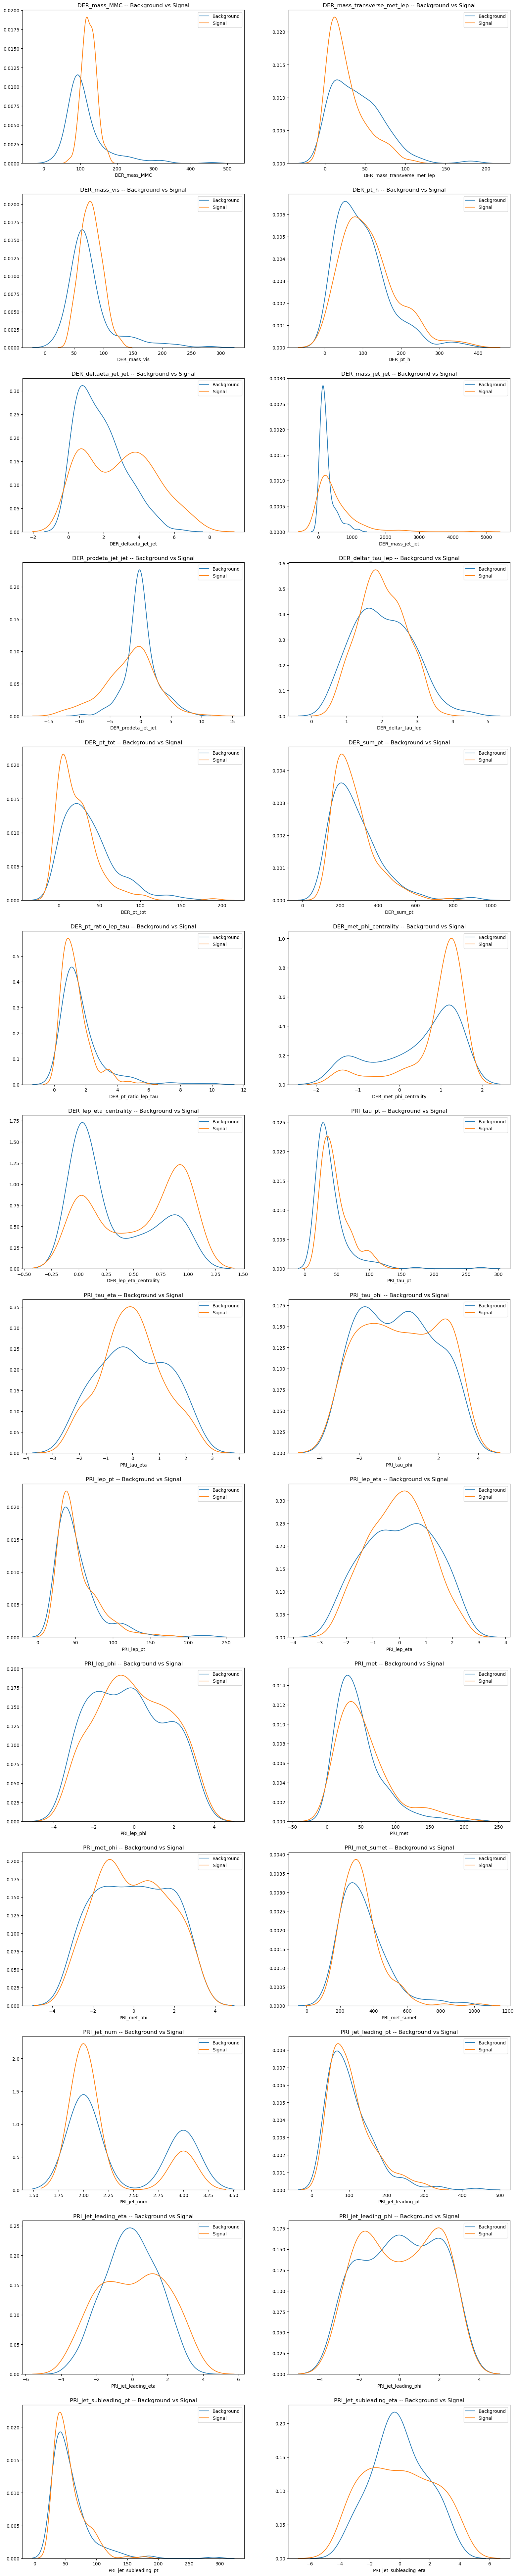

In [94]:
# Plotting the 3rd randomized data

# Looping through each variable in the two random 200 background and signal events and plotting two respective lines.
# The greater the y value, the greater the likeleyhood of that variable to signify backgreound vs signal.
fig, axes = plt.subplots(14, 2, figsize=(19,100))
for ax, (col_b, background_series), (col_s, signal_series), title, xlabel in zip(axes.ravel(), 
    df_small_background3[background_columns].items(),
    df_small_signal3[signal_columns].items(), titles, xlabels):
    sns.kdeplot(background_series.values, ax=ax, label='Background')
    sns.kdeplot(signal_series.values, ax=ax, label='Signal')
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
plt.savefig('Signal_vs_Background.png', dpi=300, bbox_inches='tight')

In [ ]:
# Due to the similarity of each set of random 200 events, I only saved the first set.

# This outputs the same graphs as above but within their own plot which allows better quality saving of images
for (col_b, background_series), (col_s, signal_series), title, xlabel in zip(df_small_background[background_columns].items(),
        df_small_signal[signal_columns].items(), titles, xlabels):
    fig, ax = plt.subplots(figsize=(6, 4))  
    sns.kdeplot(background_series, ax=ax, label='Background')
    sns.kdeplot(signal_series, ax=ax, label='Signal')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend()
    fig.savefig(f"{col_b}_kde.png", dpi=400, bbox_inches='tight')
    plt.close(fig)